In [10]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))
import stellar_classification as sc
from sklearn.metrics import accuracy_score
from stellar_classification.models.trees import SimpleRandomForest

In [11]:
#importo i dati 

data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, target_col='class', test_size=0.2, val_ratio=0.25,
    random_state=42, apply_outlier_removal=True
)
class_names = list(label_encoder.classes_)

Outliers removed: 8,715 rows  (91,285 remain)


In [12]:
#train su random forest ed extra trees
models = sc.train_trees_with_tuning(X_train, y_train, X_val, y_val, n_iter=5, cv=3)
rf_model = models['Random Forest']
et_model = models['Extra Trees']

Random Forest best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
  [Train] Acc=98.08%  F1=0.9808
  [Val] Acc=90.35%  F1=0.8763
Extra Trees best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
  [Train] Acc=99.20%  F1=0.9920
  [Val] Acc=90.27%  F1=0.8749


In [13]:
#evaluate test set
rf_metrics = sc.evaluate_test_set(y_test, rf_model.predict(X_test), 'Random Forest')
et_metrics = sc.evaluate_test_set(y_test, et_model.predict(X_test), 'Extra Trees')

sc.print_metrics(rf_metrics)
sc.print_metrics(et_metrics)


Random Forest:
  Accuracy  : 90.69%
  Precision: 0.8787
  Recall   : 0.8838
  F1       : 0.8806
  Confusion Matrix:
[[10187   356   238]
 [  216  3102   230]
 [  274   385  3269]]

Extra Trees:
  Accuracy  : 90.41%
  Precision: 0.8767
  Recall   : 0.8782
  F1       : 0.8765
  Confusion Matrix:
[[10210   345   226]
 [  225  3109   214]
 [  319   422  3187]]


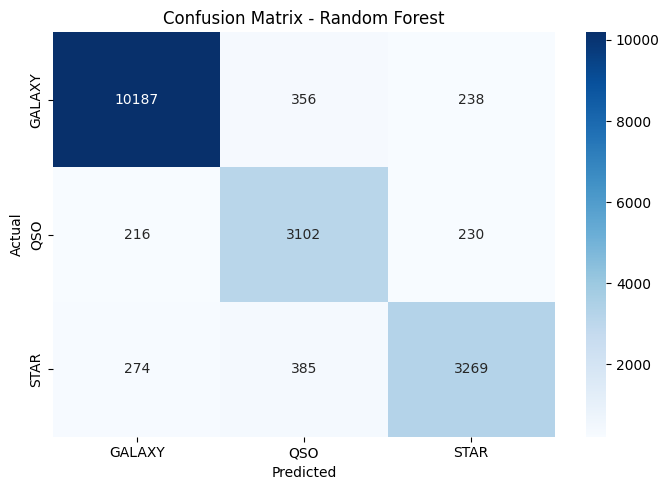

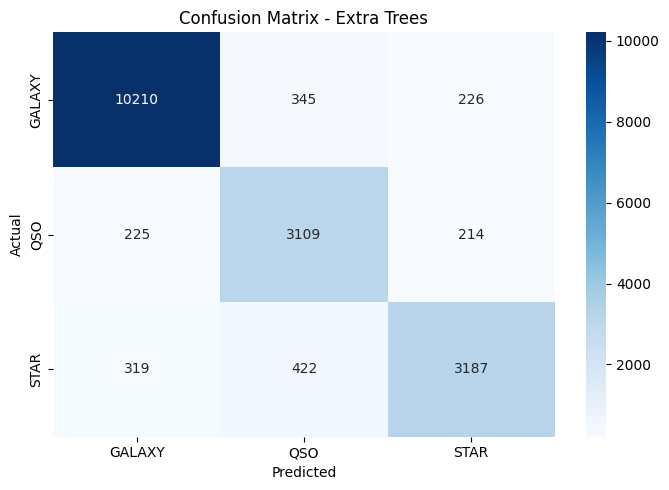

In [14]:
#matrici di confusione per i due modelli 

sc.plot_confusion_matrix(rf_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Random Forest')
sc.plot_confusion_matrix(et_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Extra Trees')

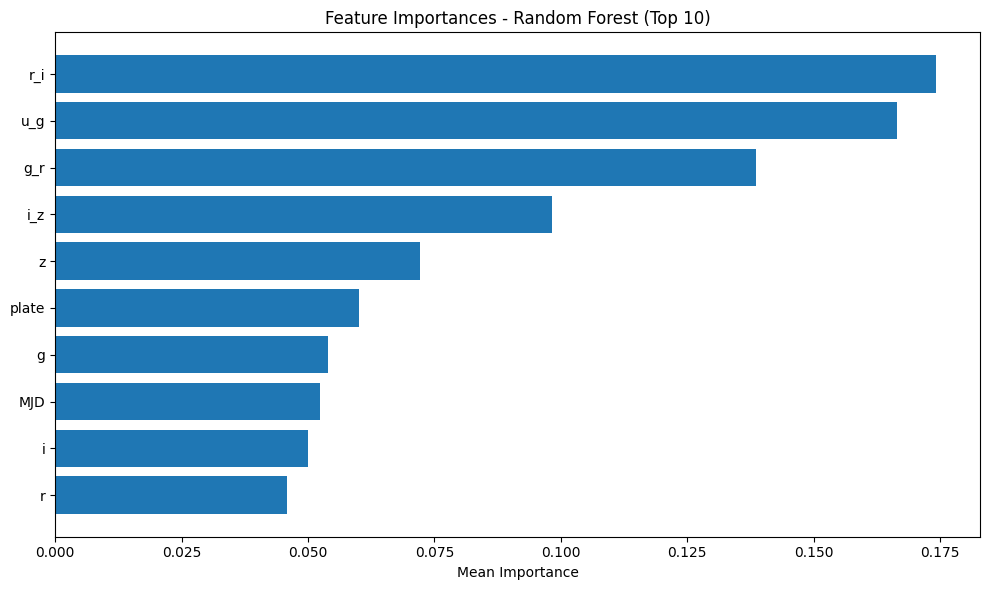

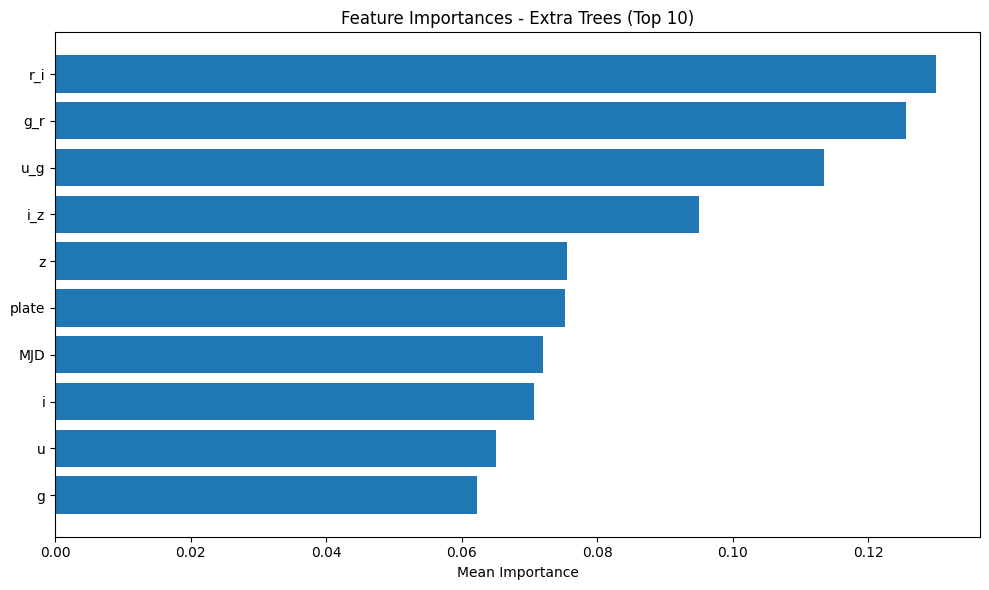

In [15]:
#faccio la fetaure importance interna alle random forest e extra trees

for name, model in [('Random Forest', rf_model), ('Extra Trees', et_model)]:
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    sc.plot_permutation_importance(imp, top_n=10, title=f'Feature Importances - {name}')

In [16]:
#vedo le feature in ordine di importanza 
imp_order = pd.Series(rf_model.feature_importances_, index=feature_names)\
              .sort_values(ascending=False).index.tolist()
print( 'in ordine le feature piu importanti sono:')
for i, a in enumerate( imp_order):
    print( f'{i} -> {a}')

in ordine le feature piu importanti sono:
0 -> r_i
1 -> u_g
2 -> g_r
3 -> i_z
4 -> z
5 -> plate
6 -> g
7 -> MJD
8 -> i
9 -> r
10 -> u
11 -> alpha
12 -> delta
